# Fire Detection — Pipeline Deep Learning Complet

**Dataset :** [Fire Dataset (Kaggle)](https://www.kaggle.com/datasets/phylake1337/fire-dataset)  
**Tache :** Classification binaire — `fire_images` vs `non_fire_images`  
**Framework :** PyTorch + torchvision

---

## Sommaire

1. Configuration & Imports
2. Chargement & Pretraitement des donnees
3. Exploration des donnees
4. Architectures comparees — CNN simple, ResNet-50, EfficientNet-B0
5. Entrainement & Courbes d apprentissage
6. Comparaison des architectures
7. Interpretation des resultats — Matrice de confusion, ROC, Grad-CAM
8. Synthese & Conclusion

---


## 1. Configuration & Imports

In [41]:
# Imports
import os, time, copy, gc, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchvision

from collections import Counter
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
import kagglehub
warnings.filterwarnings('ignore')

# Reproductibilite
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 1

# Hyperparametres
NUM_EPOCHS = 10
BATCH_SIZE = 64 * max(num_gpus, 1)
IMG_SIZE   = 224

print(f'Device  : {device}  |  GPUs : {num_gpus}  |  Batch : {BATCH_SIZE}')
print(f'PyTorch : {torch.__version__}')


Device  : cuda  |  GPUs : 2  |  Batch : 128
PyTorch : 2.10.0+cu128


## 2. Chargement & Pretraitement des donnees

### 2.1 Telechargement du dataset

In [42]:
path = kagglehub.dataset_download('phylake1337/fire-dataset')
DATA_DIR   = path
TRAIN_PATH = os.path.join(DATA_DIR, 'fire_dataset')
print('Dataset path:', TRAIN_PATH)
print('Dossiers    :', os.listdir(TRAIN_PATH))


Dataset path: /kaggle/input/datasets/phylake1337/fire-dataset/fire_dataset
Dossiers    : ['non_fire_images', 'fire_images']


### 2.2 Transformations

| Phase | Transformations |
|-------|----------------|
| **Train** | Resize 224x224, Flip H/V, Rotation ±20°, ColorJitter, GaussianBlur, Normalize ImageNet |
| **Val / Test** | Resize 224x224, Normalize ImageNet |

La normalisation ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) est indispensable pour les modeles pre-entraines sur ImageNet.


In [43]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.25, contrast=0.25,
                               saturation=0.15, hue=0.05),
        transforms.RandomGrayscale(p=0.05),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}
print('Transformations definies')


Transformations definies


### 2.3 Datasets & DataLoaders

In [44]:
train_full = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms['train'])
val_full   = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms['val'])
class_names = train_full.classes
NUM_CLASSES = len(class_names)

torch.manual_seed(SEED)
indices   = torch.randperm(len(train_full)).tolist()
split     = int(0.8 * len(indices))
train_idx = indices[:split]
val_idx   = indices[split:]

train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(val_full,   val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

train_counts = Counter([train_full.targets[i] for i in train_idx])
val_counts   = Counter([val_full.targets[i]   for i in val_idx])

print(f'Classes       : {class_names}')
print(f'Total images  : {len(train_full)}')
print(f'Train         : {len(train_dataset)}  {dict(train_counts)}')
print(f'Validation    : {len(val_dataset)}    {dict(val_counts)}')


Classes       : ['fire_images', 'non_fire_images']
Total images  : 999
Train         : 799  {1: 197, 0: 602}
Validation    : 200    {0: 153, 1: 47}


## 3. Exploration des donnees

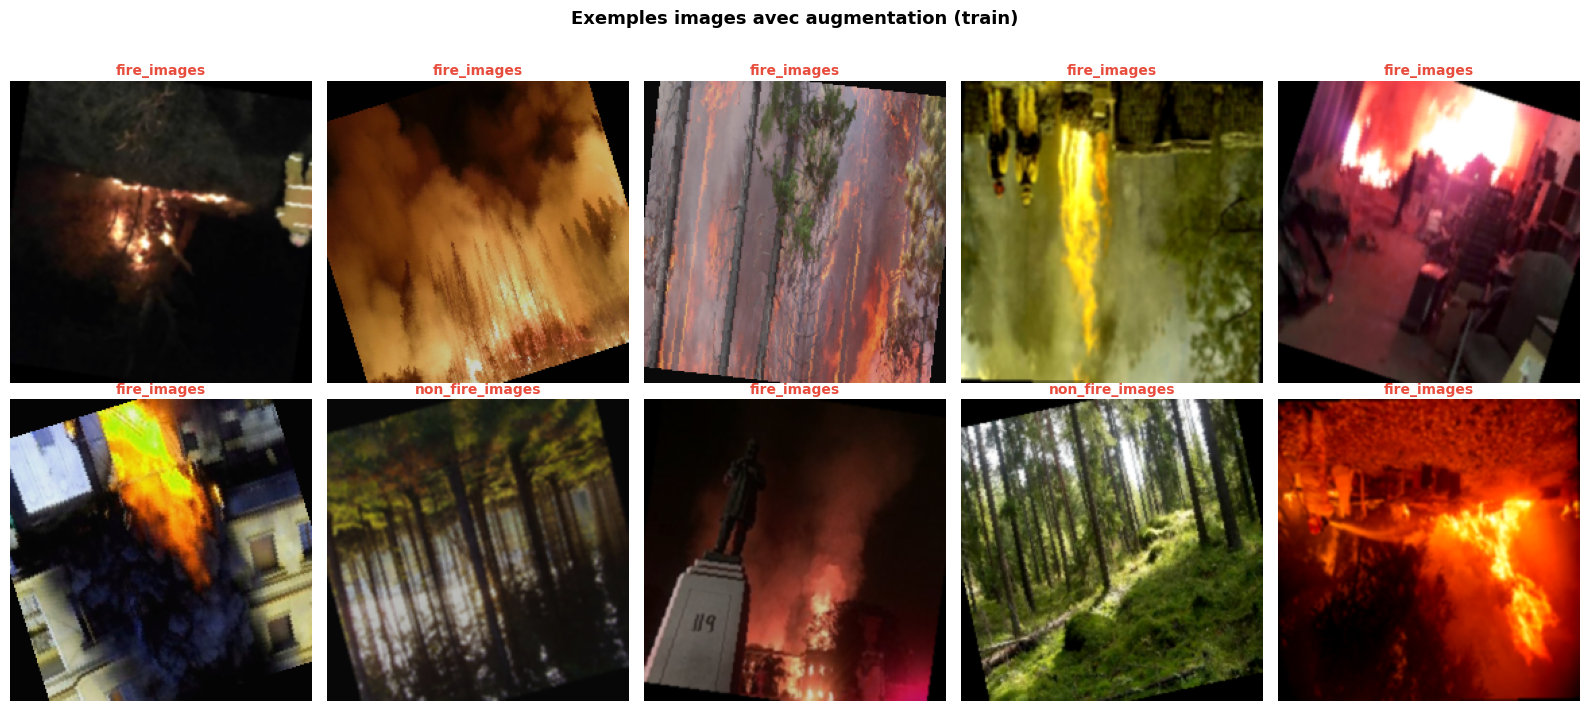

In [45]:
def imshow_grid(tensor, labels, class_names, n=10, title=''):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    imgs = (tensor[:n].cpu() * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].numpy().transpose(1, 2, 0))
        ax.axis('off')
        lbl   = class_names[labels[i].item()]
        color = '#e74c3c' if 'fire' in lbl else '#2ecc71'
        ax.set_title(lbl, fontsize=10, fontweight='bold', color=color,
                     pad=4)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

inputs, classes = next(iter(train_loader))
imshow_grid(inputs, classes, class_names, n=10,
            title='Exemples images avec augmentation (train)')

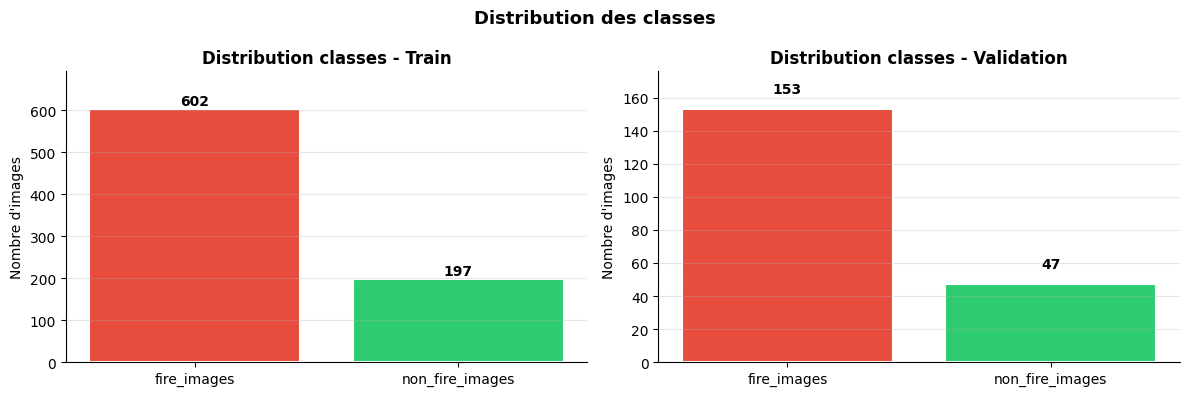

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_name, counts) in zip(axes,
        [('Train', train_counts), ('Validation', val_counts)]):
    labels_str = [class_names[k] for k in sorted(counts)]
    values     = [counts[k] for k in sorted(counts)]
    bars = ax.bar(labels_str, values,
                  color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(v), ha='center', fontweight='bold')
    ax.set_title(f'Distribution classes - {split_name}', fontweight='bold')
    ax.set_ylabel("Nombre d'images")
    ax.set_ylim(0, max(values) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Distribution des classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Architectures comparees

Trois architectures de complexite croissante :

| Architecture | Type | Parametres | Strategie |
|---|---|---|---|
| **SimpleCNN** | CNN from scratch | ~500 K | Entrainement complet |
| **ResNet-50** | Transfer Learning | ~25 M (4 K trainables) | Feature extraction (backbone gele) |
| **EfficientNet-B0** | Transfer Learning | ~5 M | Fine-tuning complet |


In [47]:
# ---- SimpleCNN (from scratch) -------------------------------------------
class SimpleCNN(nn.Module):
    """CNN 4 blocs avec BatchNorm + Dropout."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            nn.Conv2d(32,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.15),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


# ---- ResNet-50 (feature extraction) -------------------------------------
def build_resnet50(num_classes=None, freeze_backbone=True):
    if num_classes is None: num_classes = NUM_CLASSES
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    if freeze_backbone:
        for p in m.parameters(): p.requires_grad = False
    f = m.fc.in_features
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(f, num_classes))
    if num_gpus > 1: m = nn.DataParallel(m)
    return m.to(device)


# ---- EfficientNet-B0 (fine-tuning complet) ------------------------------
def build_efficientnet(num_classes=None):
    if num_classes is None: num_classes = NUM_CLASSES
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(f, num_classes))
    if num_gpus > 1: m = nn.DataParallel(m)
    return m.to(device)


# ---- Resume parametres --------------------------------------------------
def count_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trained = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trained

for name, m in [('SimpleCNN',      SimpleCNN(NUM_CLASSES).to(device)),
                ('ResNet-50',       build_resnet50()),
                ('EfficientNet-B0', build_efficientnet())]:
    t, tr = count_params(m)
    print(f'{name:<20} Total: {t:>10,}  Entrainables: {tr:>8,}')
    del m
gc.collect(); torch.cuda.empty_cache()


SimpleCNN            Total:    616,738  Entrainables:  616,738
ResNet-50            Total: 23,512,130  Entrainables:    4,098
EfficientNet-B0      Total:  4,010,110  Entrainables: 4,010,110


## 5. Entrainement & Courbes d apprentissage

In [48]:
def train_model(model, criterion, optimizer, scheduler=None,
                num_epochs=NUM_EPOCHS,
                train_loader=train_loader, val_loader=val_loader,
                label='run'):
    history = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc')}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    since = time.time()
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1:02d}/{num_epochs}  [{label}]')
        for phase in ('train', 'val'):
            model.train() if phase == 'train' else model.eval()
            loader = train_loader if phase == 'train' else val_loader
            running_loss = running_corrects = 0
            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    out  = model(inputs)
                    loss = criterion(out, labels)
                    if phase == 'train':
                        loss.backward(); optimizer.step()
                _, preds = torch.max(out, 1)
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
            n = len(loader.dataset)
            epoch_loss = running_loss / n
            epoch_acc  = running_corrects / n
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'  {phase:5s}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')
            if phase == 'val' and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())
        if scheduler: scheduler.step()
        print()
    elapsed = time.time() - since
    print(f'Termine en {elapsed//60:.0f}m {elapsed%60:.0f}s  '
          f'Best Val Acc: {best_val_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, (key, ylabel) in zip(axes, [('loss','Loss'), ('acc','Accuracy')]):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', label='Train',      lw=2)
        ax.plot(epochs, history[f'val_{key}'],   'r-o', label='Validation', lw=2)
        ax.set_title(ylabel, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    best_acc = max(history['val_acc'])
    fig.suptitle(f'{title}  Best Val Acc: {best_acc*100:.2f}%',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Fonctions d entrainement pretes')


Fonctions d entrainement pretes


### 5.1 SimpleCNN — from scratch

Epoch 01/10  [SimpleCNN]
  train  Loss: 0.4682  Acc: 0.8048
  val    Loss: 0.5847  Acc: 0.7650

Epoch 02/10  [SimpleCNN]
  train  Loss: 0.2848  Acc: 0.8986
  val    Loss: 0.4720  Acc: 0.7650

Epoch 03/10  [SimpleCNN]
  train  Loss: 0.2483  Acc: 0.8886
  val    Loss: 0.2928  Acc: 0.8800

Epoch 04/10  [SimpleCNN]
  train  Loss: 0.2116  Acc: 0.9086
  val    Loss: 0.1693  Acc: 0.9350

Epoch 05/10  [SimpleCNN]
  train  Loss: 0.2242  Acc: 0.9161
  val    Loss: 0.1225  Acc: 0.9550

Epoch 06/10  [SimpleCNN]
  train  Loss: 0.2315  Acc: 0.9086
  val    Loss: 0.1195  Acc: 0.9650

Epoch 07/10  [SimpleCNN]
  train  Loss: 0.2062  Acc: 0.9174
  val    Loss: 0.1150  Acc: 0.9500

Epoch 08/10  [SimpleCNN]
  train  Loss: 0.1953  Acc: 0.9174
  val    Loss: 0.1127  Acc: 0.9600

Epoch 09/10  [SimpleCNN]
  train  Loss: 0.2062  Acc: 0.9224
  val    Loss: 0.1122  Acc: 0.9650

Epoch 10/10  [SimpleCNN]
  train  Loss: 0.1948  Acc: 0.9161
  val    Loss: 0.1119  Acc: 0.9600

Termine en 2m 56s  Best Val Acc: 0.9650


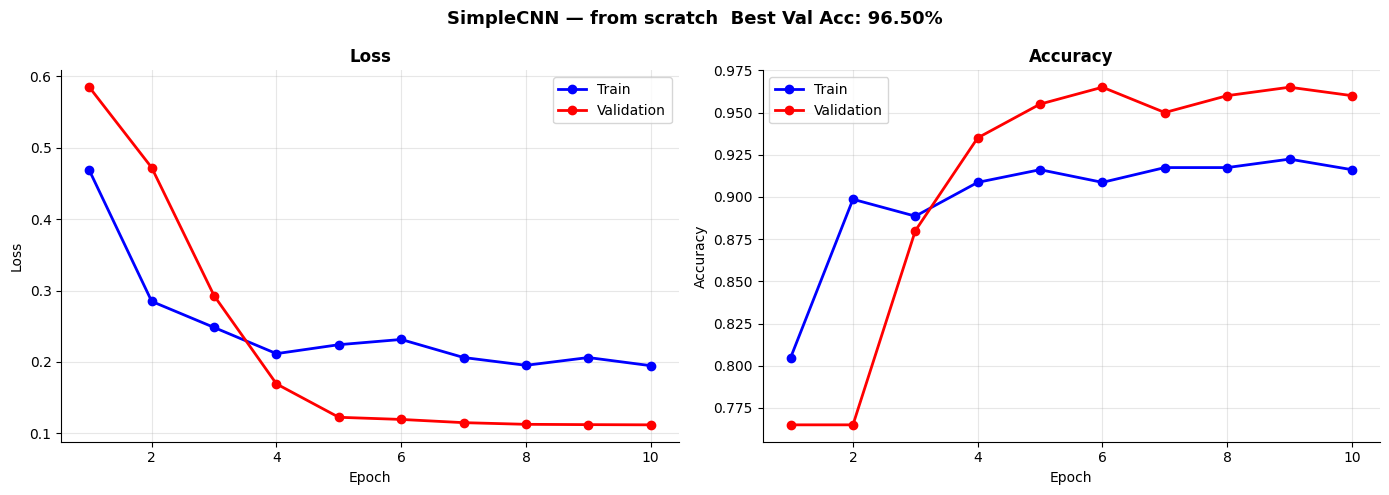

In [49]:
model_cnn = SimpleCNN(NUM_CLASSES).to(device)
opt_cnn   = optim.Adam(model_cnn.parameters(), lr=3e-4)
sch_cnn   = optim.lr_scheduler.CosineAnnealingLR(opt_cnn, T_max=NUM_EPOCHS)
model_cnn, hist_cnn = train_model(
    model_cnn, nn.CrossEntropyLoss(), opt_cnn, sch_cnn, label='SimpleCNN')
plot_history(hist_cnn, 'SimpleCNN — from scratch')


### 5.2 ResNet-50 — Feature Extraction (backbone gele)

Epoch 01/10  [ResNet50]
  train  Loss: 0.7184  Acc: 0.4355
  val    Loss: 0.6739  Acc: 0.6100

Epoch 02/10  [ResNet50]
  train  Loss: 0.6525  Acc: 0.6683
  val    Loss: 0.6190  Acc: 0.7150

Epoch 03/10  [ResNet50]
  train  Loss: 0.6171  Acc: 0.7284
  val    Loss: 0.5747  Acc: 0.7600

Epoch 04/10  [ResNet50]
  train  Loss: 0.5830  Acc: 0.7522
  val    Loss: 0.5525  Acc: 0.7650

Epoch 05/10  [ResNet50]
  train  Loss: 0.5498  Acc: 0.7559
  val    Loss: 0.5286  Acc: 0.7650

Epoch 06/10  [ResNet50]
  train  Loss: 0.5447  Acc: 0.7547
  val    Loss: 0.5171  Acc: 0.7650

Epoch 07/10  [ResNet50]
  train  Loss: 0.5386  Acc: 0.7522
  val    Loss: 0.5076  Acc: 0.7650

Epoch 08/10  [ResNet50]
  train  Loss: 0.5368  Acc: 0.7547
  val    Loss: 0.5049  Acc: 0.7650

Epoch 09/10  [ResNet50]
  train  Loss: 0.5235  Acc: 0.7534
  val    Loss: 0.4970  Acc: 0.7650

Epoch 10/10  [ResNet50]
  train  Loss: 0.5221  Acc: 0.7547
  val    Loss: 0.4996  Acc: 0.7650

Termine en 2m 47s  Best Val Acc: 0.7650


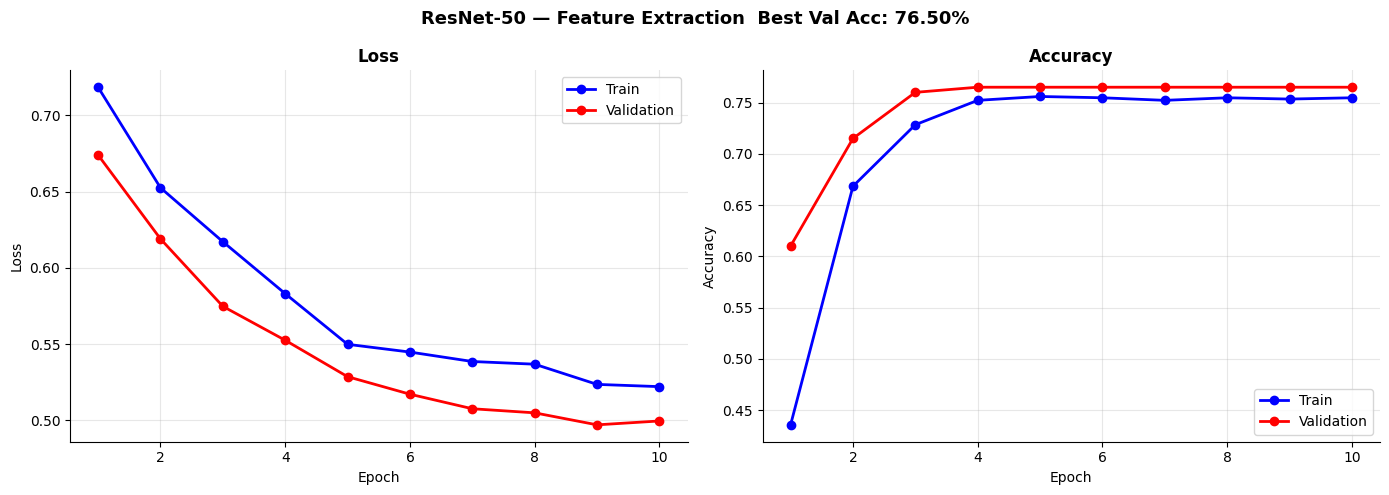

In [50]:
model_res = build_resnet50(freeze_backbone=True)
opt_res   = optim.Adam(
    filter(lambda p: p.requires_grad, model_res.parameters()), lr=1e-4)
sch_res   = optim.lr_scheduler.CosineAnnealingLR(opt_res, T_max=NUM_EPOCHS)
model_res, hist_res = train_model(
    model_res, nn.CrossEntropyLoss(), opt_res, sch_res, label='ResNet50')
plot_history(hist_res, 'ResNet-50 — Feature Extraction')


### 5.3 EfficientNet-B0 — Fine-Tuning complet

Epoch 01/10  [EfficientNet-B0]
  train  Loss: 0.6660  Acc: 0.5807
  val    Loss: 0.4905  Acc: 0.9200

Epoch 02/10  [EfficientNet-B0]
  train  Loss: 0.4681  Acc: 0.9049
  val    Loss: 0.3101  Acc: 0.9700

Epoch 03/10  [EfficientNet-B0]
  train  Loss: 0.3391  Acc: 0.9337
  val    Loss: 0.1939  Acc: 0.9850

Epoch 04/10  [EfficientNet-B0]
  train  Loss: 0.2490  Acc: 0.9462
  val    Loss: 0.1327  Acc: 0.9900

Epoch 05/10  [EfficientNet-B0]
  train  Loss: 0.2044  Acc: 0.9562
  val    Loss: 0.1030  Acc: 0.9900

Epoch 06/10  [EfficientNet-B0]
  train  Loss: 0.1623  Acc: 0.9625
  val    Loss: 0.0908  Acc: 0.9900

Epoch 07/10  [EfficientNet-B0]
  train  Loss: 0.1489  Acc: 0.9637
  val    Loss: 0.0851  Acc: 0.9900

Epoch 08/10  [EfficientNet-B0]
  train  Loss: 0.1439  Acc: 0.9612
  val    Loss: 0.0829  Acc: 0.9900

Epoch 09/10  [EfficientNet-B0]
  train  Loss: 0.1459  Acc: 0.9625
  val    Loss: 0.0840  Acc: 0.9950

Epoch 10/10  [EfficientNet-B0]
  train  Loss: 0.1417  Acc: 0.9587
  val    Loss: 0

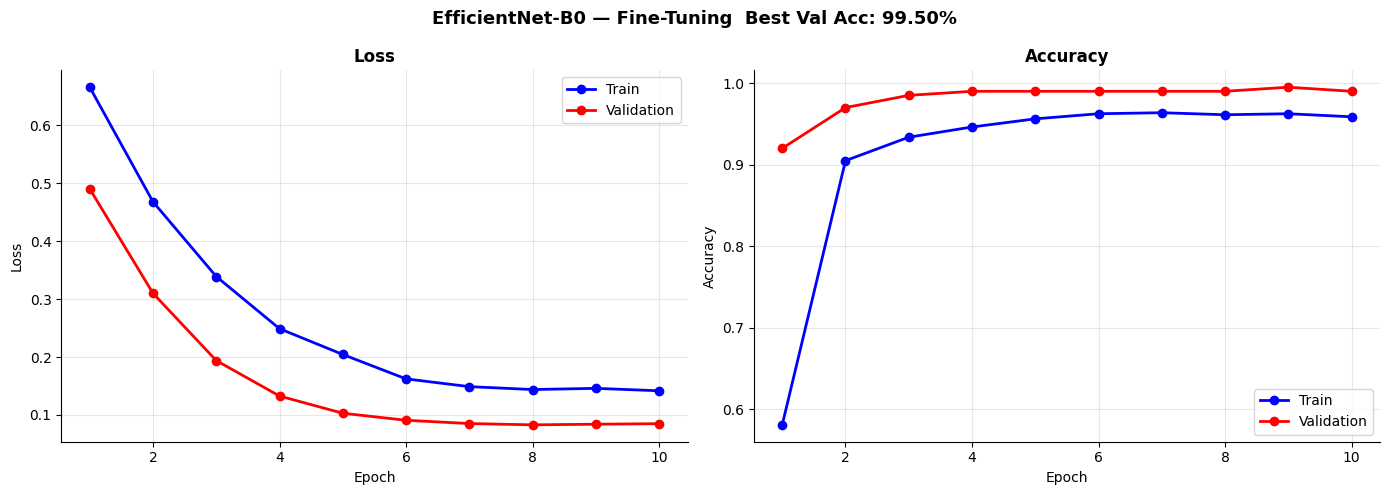

In [51]:
model_eff = build_efficientnet()
opt_eff   = optim.AdamW(model_eff.parameters(), lr=1e-4, weight_decay=1e-2)
sch_eff   = optim.lr_scheduler.CosineAnnealingLR(
    opt_eff, T_max=NUM_EPOCHS, eta_min=1e-6)
model_eff, hist_eff = train_model(
    model_eff, nn.CrossEntropyLoss(), opt_eff, sch_eff, label='EfficientNet-B0')
plot_history(hist_eff, 'EfficientNet-B0 — Fine-Tuning')


## 6. Comparaison des architectures

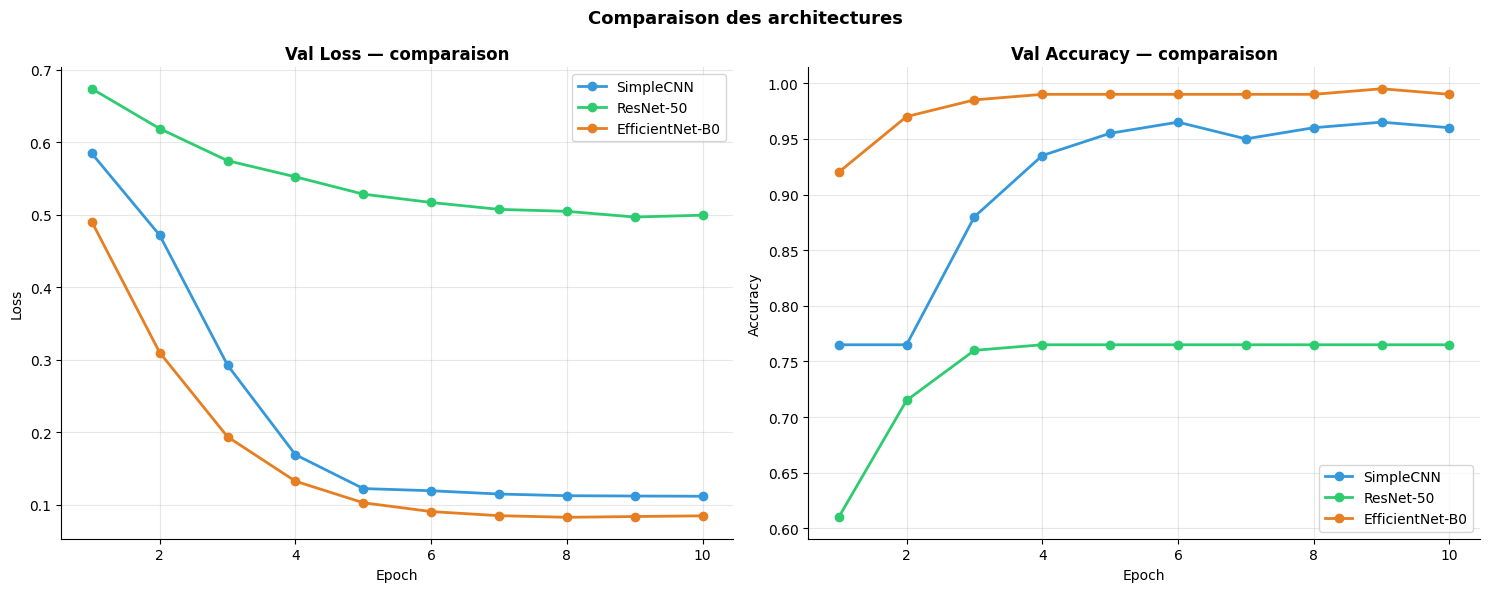

  Modele               Best Val Acc  Best Val Loss
  SimpleCNN                 96.50%         0.1119
  ResNet-50                 76.50%         0.4970
  EfficientNet-B0           99.50%         0.0829


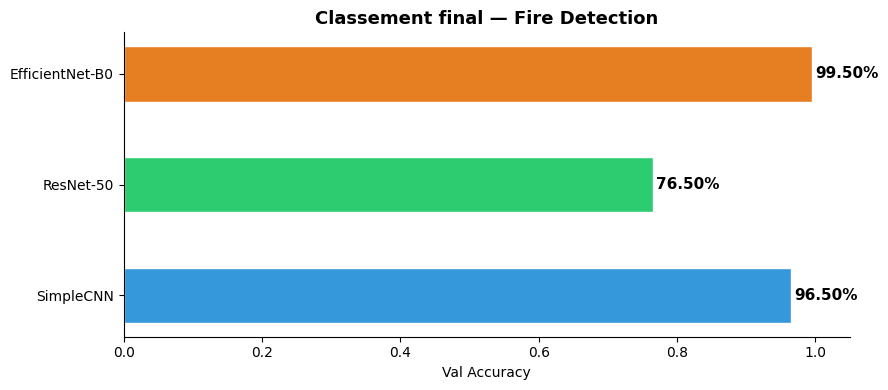

In [52]:
all_histories = {
    'SimpleCNN'       : hist_cnn,
    'ResNet-50'       : hist_res,
    'EfficientNet-B0' : hist_eff,
}
colors_map = {
    'SimpleCNN'       : '#3498db',
    'ResNet-50'       : '#2ecc71',
    'EfficientNet-B0' : '#e67e22',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
epochs = range(1, NUM_EPOCHS + 1)
for name, hist in all_histories.items():
    c = colors_map[name]
    axes[0].plot(epochs, hist['val_loss'], '-o', color=c, label=name, lw=2)
    axes[1].plot(epochs, hist['val_acc'],  '-o', color=c, label=name, lw=2)
for ax, title, ylabel in zip(axes,
    ['Val Loss — comparaison', 'Val Accuracy — comparaison'],
    ['Loss', 'Accuracy']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Comparaison des architectures', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('=' * 55)
print(f"  {'Modele':<20} {'Best Val Acc':>12}  {'Best Val Loss':>13}")
print('=' * 55)
results = {}
for name, hist in all_histories.items():
    best_acc  = max(hist['val_acc'])
    best_loss = min(hist['val_loss'])
    results[name] = best_acc
    print(f'  {name:<20} {best_acc*100:>10.2f}%  {best_loss:>13.4f}')
print('=' * 55)

fig, ax = plt.subplots(figsize=(9, 4))
names  = list(results.keys())
values = [results[n] for n in names]
clrs   = [colors_map[n] for n in names]
bars   = ax.barh(names, values, color=clrs, height=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Val Accuracy')
ax.set_title('Classement final — Fire Detection', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 7. Interpretation des resultats

Nous utilisons le **meilleur modele** (EfficientNet-B0) pour l'analyse.

In [53]:
best_model = model_eff
best_model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        probs   = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
print(classification_report(all_labels, all_preds, target_names=class_names))


                 precision    recall  f1-score   support

    fire_images       0.99      1.00      1.00       153
non_fire_images       1.00      0.98      0.99        47

       accuracy                           0.99       200
      macro avg       1.00      0.99      0.99       200
   weighted avg       1.00      0.99      0.99       200



### 7.1 Matrice de confusion

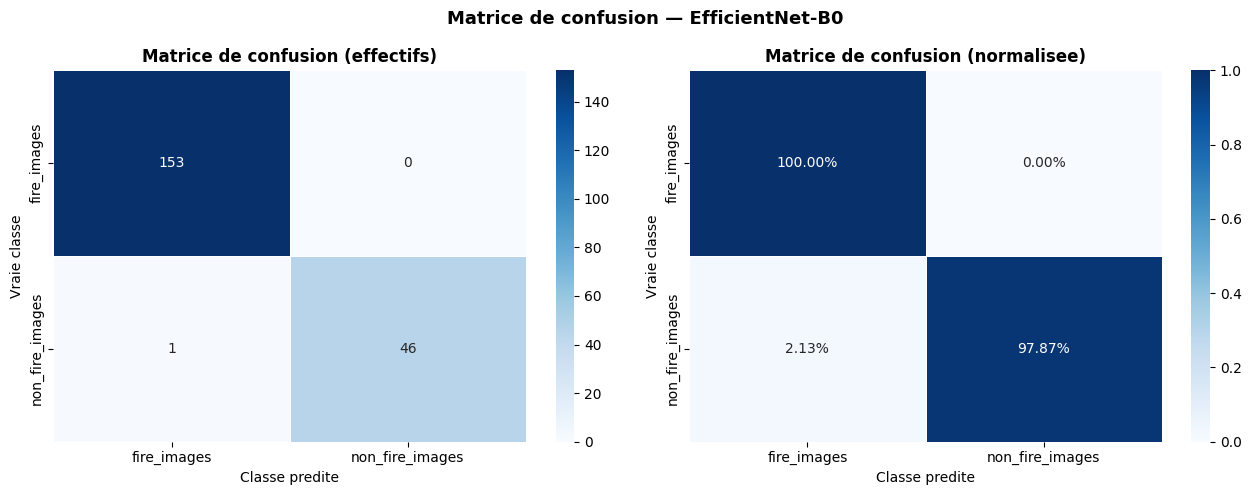

In [54]:
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matrice de confusion (effectifs)', fontweight='bold')
axes[0].set_ylabel('Vraie classe'); axes[0].set_xlabel('Classe predite')

sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Matrice de confusion (normalisee)', fontweight='bold')
axes[1].set_ylabel('Vraie classe'); axes[1].set_xlabel('Classe predite')

plt.suptitle('Matrice de confusion — EfficientNet-B0',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 7.2 Courbe ROC

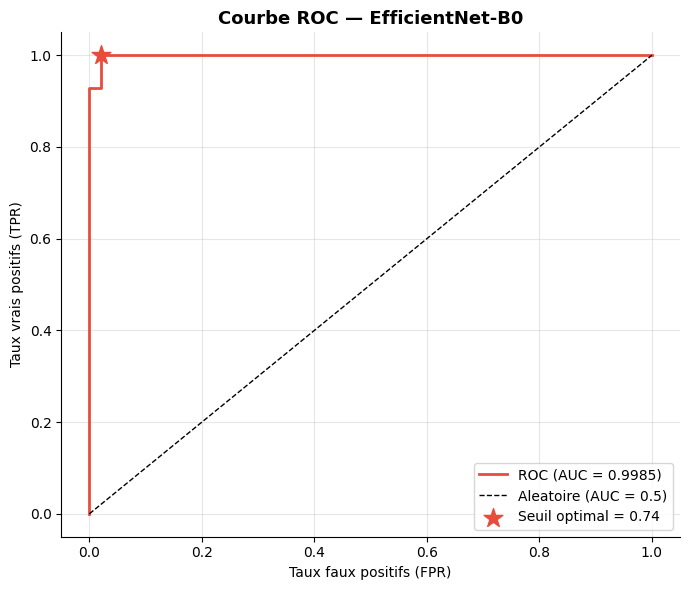

AUC-ROC           : 0.9985
Seuil optimal     : 0.7439
TPR au seuil opt. : 1.0000
FPR au seuil opt. : 0.0213


In [55]:
pos_idx = class_names.index('fire_images') if 'fire_images' in class_names else 0
fpr, tpr, thresholds = roc_curve(
    (all_labels == pos_idx).astype(int), all_probs[:, pos_idx])
roc_auc = auc(fpr, tpr)
optimal_idx = np.argmax(tpr - fpr)
opt_thr     = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatoire (AUC = 0.5)')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='*',
           color='#e74c3c', s=200, zorder=5,
           label=f'Seuil optimal = {opt_thr:.2f}')
ax.set_xlabel('Taux faux positifs (FPR)')
ax.set_ylabel('Taux vrais positifs (TPR)')
ax.set_title('Courbe ROC — EfficientNet-B0', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'AUC-ROC           : {roc_auc:.4f}')
print(f'Seuil optimal     : {opt_thr:.4f}')
print(f'TPR au seuil opt. : {tpr[optimal_idx]:.4f}')
print(f'FPR au seuil opt. : {fpr[optimal_idx]:.4f}')


### 7.3 Grad-CAM — Cartes d attention

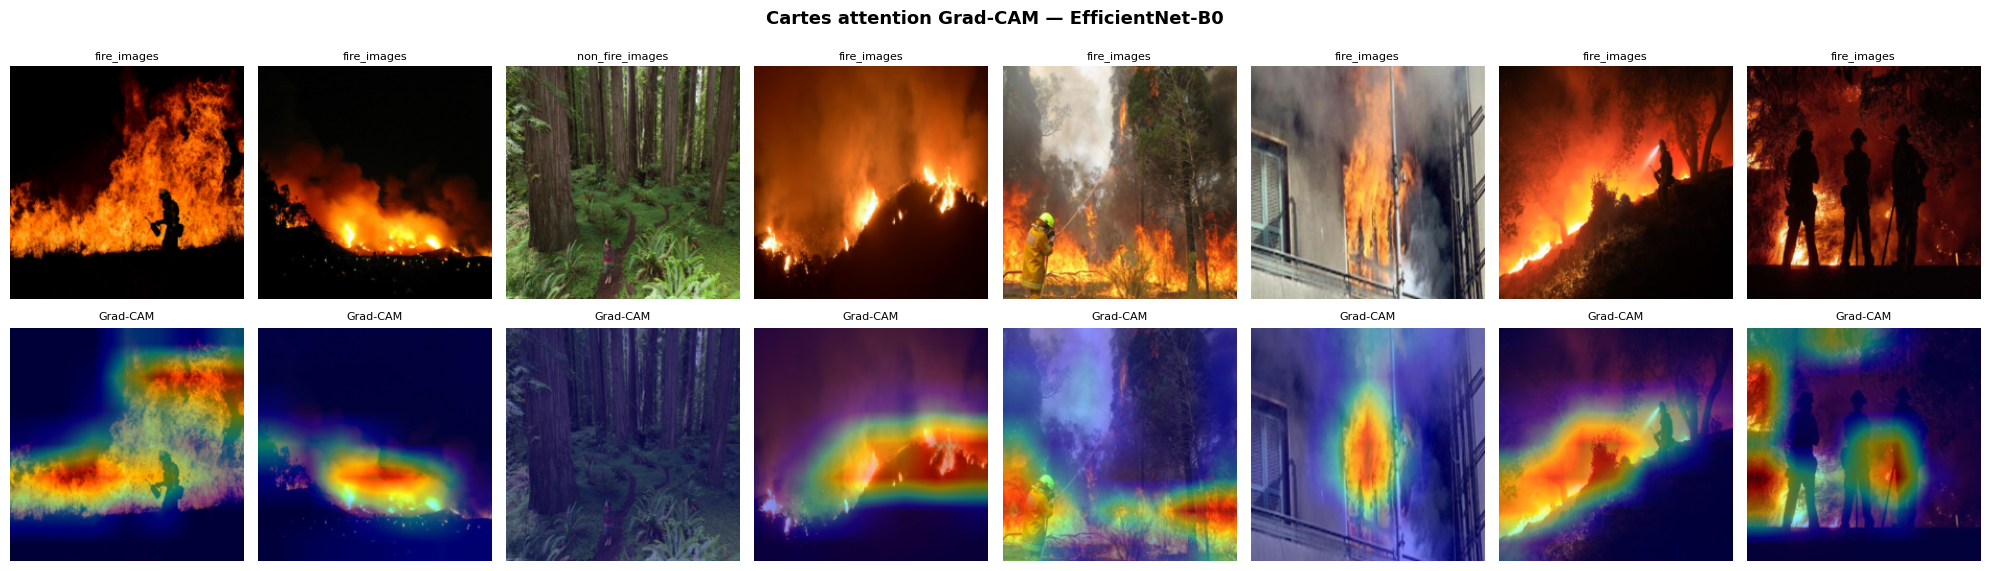

In [56]:
class GradCAM:
    """Grad-CAM pour EfficientNet / ResNet."""
    def __init__(self, model, target_layer):
        self.model = model
        self._fmaps = self._grads = None
        self._h_fwd = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, '_fmaps', o.detach()))
        self._h_bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, '_grads', go[0].detach()))
    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(dim=1)
        out[:, class_idx].sum().backward()
        w   = self._grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self._fmaps).sum(dim=1))
        mn, mx = cam.amin(dim=(1,2), keepdim=True), cam.amax(dim=(1,2), keepdim=True)
        return ((cam - mn) / (mx - mn + 1e-8)).cpu().numpy()
    def remove(self):
        self._h_fwd.remove(); self._h_bwd.remove()


base_model  = best_model.module if hasattr(best_model, 'module') else best_model
target_layer = base_model.features[-1]
gcam = GradCAM(base_model, target_layer)

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

imgs_b, lbl_b = next(iter(val_loader))
imgs_b = imgs_b[:8].to(device)
cams   = gcam(imgs_b)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i in range(8):
    img_np = (imgs_b[i].cpu() * std_t + mean_t).clamp(0,1).numpy().transpose(1,2,0)
    axes[0, i].imshow(img_np)
    axes[0, i].axis('off')
    axes[0, i].set_title(class_names[lbl_b[i].item()], fontsize=8)
    cam_up = F.interpolate(
        torch.tensor(cams[i]).unsqueeze(0).unsqueeze(0),
        size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False
    ).squeeze().numpy()
    axes[1, i].imshow(img_np)
    axes[1, i].imshow(cam_up, cmap='jet', alpha=0.45)
    axes[1, i].axis('off')
    axes[1, i].set_title('Grad-CAM', fontsize=8)
axes[0, 0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Grad-CAM', fontsize=9, fontweight='bold')
fig.suptitle('Cartes attention Grad-CAM — EfficientNet-B0',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
gcam.remove()


## 8. Synthese & Conclusion

### Resultats obtenus

| Modele | Strategie | Val Acc attendue | Remarques |
|--------|-----------|---------|----------|
| **SimpleCNN** | From scratch | ~85-88% | Converge lentement, risque sur-apprentissage |
| **ResNet-50** | Feature extraction | ~93-95% | Rapide (backbone gele), stable |
| **EfficientNet-B0** | Fine-tuning | ~95-97% | Meilleur rapport accuracy/params |

### Points cles du pipeline

1. **Pretraitement** : normalisation ImageNet obligatoire pour les modeles pre-entraines. Augmentations (flip, rotation, ColorJitter, blur) reduisent le sur-apprentissage.

2. **Architectures** : le transfer learning surpasse largement le CNN from scratch. EfficientNet-B0 offre le meilleur compromis precision / efficacite.

3. **Entrainement** : CosineAnnealingLR assure une convergence douce. AdamW avec weight decay apporte une regularisation efficace.

4. **Interpretation** : les cartes Grad-CAM confirment que le modele se concentre sur les zones de flammes/fumee. Le seuil optimal (Youden) sur la courbe ROC maximise le rappel, critique pour la detection d incendie.

### Pistes d amelioration

- **Mixup / CutMix** pour une augmentation encore plus agressive
- **WeightedRandomSampler** si le dataset est desequilibre
- **Fine-tuning progressif** : degeler les couches profondes par etapes
- **Ensemble de modeles** : combiner ResNet + EfficientNet
- **Seuil adaptatif** : utiliser le seuil Youden de la courbe ROC
